In [2]:
import os
import numpy as np
import pandas as pd

#os.listdir()

In [3]:
df = pd.read_excel('Retention Rates U of L.xlsx')
print(df.shape)
print(df.describe(include='all'))
print('Available Columns:', df.columns.tolist())

# Counts & percentages of missing values
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_summary = (
    pd.DataFrame({"n_missing": missing_counts, "pct_missing": missing_pct})
    .sort_values("pct_missing", ascending=False)
)

print(df[['Category', 'entry_major']].value_counts())# summary stats
print(df[['Category', 'entry_major']].describe())


# Top 15 columns with most missing
missing_summary

(90, 8)
        ret_1to2_unit  ret_1to2_uofl  ret_1to3_unit  ret_1to3 uofl Category  \
count       90.000000      90.000000      80.000000      80.000000       90   
unique            NaN            NaN            NaN            NaN        1   
top               NaN            NaN            NaN            NaN   Cohort   
freq              NaN            NaN            NaN            NaN       90   
mean         0.682343       0.814360       0.538173       0.711921      NaN   
std          0.087352       0.059922       0.115707       0.076801      NaN   
min          0.391304       0.608696       0.217400       0.461500      NaN   
25%          0.637033       0.782287       0.462650       0.676554      NaN   
50%          0.683216       0.812625       0.555556       0.710850      NaN   
75%          0.748200       0.850839       0.632309       0.760775      NaN   
max          0.833333       1.000000       0.750000       0.958300      NaN   

        cohort_year  cohort_count      entr

,n_missing,pct_missing
ret_1to3 uofl,10,11.11
ret_1to3_unit,10,11.11
ret_1to2_uofl,0,0.00
ret_1to2_unit,0,0.00
Category,0,0.00
cohort_year,0,0.00
cohort_count,0,0.00
entry_major,0,0.00


In [4]:
# Summary stats for retention at the unit level
print("Unit Retention (1to2):")
print(df['ret_1to2_unit'].describe())

print("\nUnit Retention (1to3):")
print(df['ret_1to3_unit'].describe())

# Summary stats for retention at UofL
print("\nUofL Retention (1to2):")
print(df['ret_1to2_uofl'].describe())

print("\nUofL Retention (1to3):")
print(df['ret_1to3 uofl'].describe())


Unit Retention (1to2):
count    90.000000
mean      0.682343
std       0.087352
min       0.391304
25%       0.637033
50%       0.683216
75%       0.748200
max       0.833333
Name: ret_1to2_unit, dtype: float64

Unit Retention (1to3):
count    80.000000
mean      0.538173
std       0.115707
min       0.217400
25%       0.462650
50%       0.555556
75%       0.632309
max       0.750000
Name: ret_1to3_unit, dtype: float64

UofL Retention (1to2):
count    90.000000
mean      0.814360
std       0.059922
min       0.608696
25%       0.782287
50%       0.812625
75%       0.850839
max       1.000000
Name: ret_1to2_uofl, dtype: float64

UofL Retention (1to3):
count    80.000000
mean      0.711921
std       0.076801
min       0.461500
25%       0.676554
50%       0.710850
75%       0.760775
max       0.958300
Name: ret_1to3 uofl, dtype: float64


----------------------------------------------
ret_1to2_unit (mean = 68.2%)  major level retention
ret_1to2_uofl (mean = 81.4%)  uofl level retention

Students are more likely to stay at UofL than to stay in their original academic unit.

The spread is fairly tight (std ~0.06–0.08), meaning most cohorts cluster around similar retention levels.

Minimums around 39% (unit) and 61% (UofL) show a few struggling cohorts.

Maximums of 83% (unit) and 100% (UofL) show some very strong cohorts.

The kind of pattern expected when students switch majors but remain enrolled.

---------------------------------------------------------------------------

--------------------------------------------------------
ret_1to3_unit (mean = 53.8%) major level retention 
ret_1to3_uofl (mean = 71.2%) uofl level retention

Retention naturally drops by year 3, but the same pattern holds:
UofL retention stays much higher than unit retention.

The wider standard deviation (0.11) for ret_1to3_unit means cohorts diverge more by year 3.

Minimums around 22% (unit) and 46% (UofL) show some cohorts with steep attrition.

Maximums of 75% (unit) and 95% (UofL) show strong long-term persistence for others.

--------------------------------------------------------------

RANDOM FOREST REGRESSION MODEL: Unit Retention
----------------------------------------

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd


# 1. Select features and target
target = 'ret_1to2_unit'

# Drop non-predictive or ID-like columns
features = df.drop(columns=[target])

# Convert categorical variables to dummies
features = pd.get_dummies(features, drop_first=True)

# Align target
y = df[target]
X = features

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Build the Random Forest model
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

# 4. Evaluate the model
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

# 5. Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("\nFeature Importance:")
print(importances.head(10))


Mean Absolute Error: 0.0304615190096352
R² Score: 0.7088583174652088

Feature Importance:
ret_1to3_unit                                                   0.513288
ret_1to2_uofl                                                   0.194405
cohort_count                                                    0.120580
ret_1to3 uofl                                                   0.096779
entry_major_School of Public Health and Information Sciences    0.021643
cohort_year                                                     0.018857
entry_major_School of Dentistry                                 0.009197
entry_major_Kent School of Social Work                          0.007162
entry_major_School of Music                                     0.006356
entry_major_College of Education and Human Development          0.003727
dtype: float64


RANDOM FOREST REGRESSION MODEL: UofL Retention
----------------------------------------

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd


# 1. Select features and target
target = 'ret_1to2_uofl'

# Drop non-predictive or ID-like columns
features = df.drop(columns=[target])

# Convert categorical variables to dummies
features = pd.get_dummies(features, drop_first=True)

# Align target
y = df[target]
X = features

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Build the Random Forest model
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

# 4. Evaluate the model
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

# 5. Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("\nFeature Importance:")
print(importances.head(10))


Mean Absolute Error: 0.025862027144069853
R² Score: -0.14577555328281333

Feature Importance:
ret_1to3 uofl                                                   0.653023
ret_1to3_unit                                                   0.125796
ret_1to2_unit                                                   0.090718
cohort_count                                                    0.068757
entry_major_School of Public Health and Information Sciences    0.028448
entry_major_Kent School of Social Work                          0.013634
cohort_year                                                     0.007626
entry_major_School of Dentistry                                 0.004162
entry_major_School of Nursing                                   0.002117
entry_major_College of Education and Human Development          0.001785
dtype: float64


OPTIONS FOR PRESENTATION VISUALS
---------------------------------

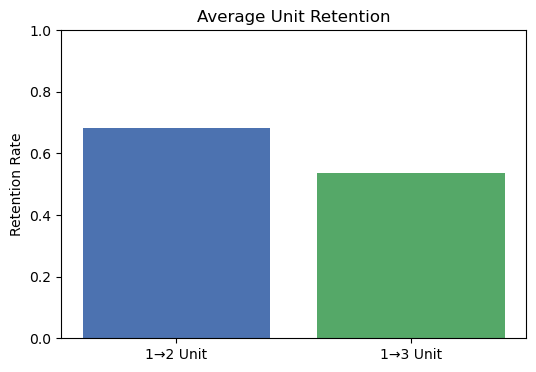

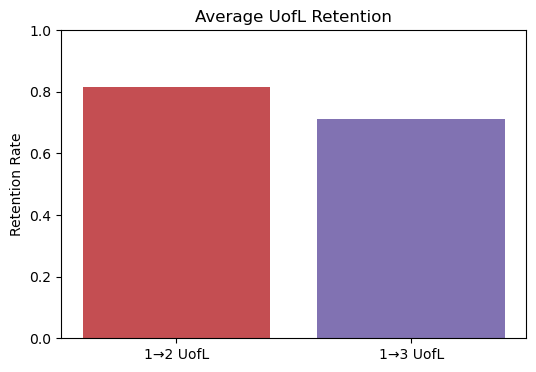

In [7]:
import matplotlib.pyplot as plt

# --- Unit Retention ---
plt.figure(figsize=(6,4))
plt.bar(['1→2 Unit', '1→3 Unit'],
        [df['ret_1to2_unit'].mean(), df['ret_1to3_unit'].mean()],
        color=['#4C72B0', '#55A868'])

plt.title('Average Unit Retention')
plt.ylabel('Retention Rate')
plt.ylim(0,1)
plt.show()

# --- UofL Retention ---
plt.figure(figsize=(6,4))
plt.bar(['1→2 UofL', '1→3 UofL'],
        [df['ret_1to2_uofl'].mean(), df['ret_1to3 uofl'].mean()],
        color=['#C44E52', '#8172B2'])

plt.title('Average UofL Retention')
plt.ylabel('Retention Rate')
plt.ylim(0,1)
plt.show()


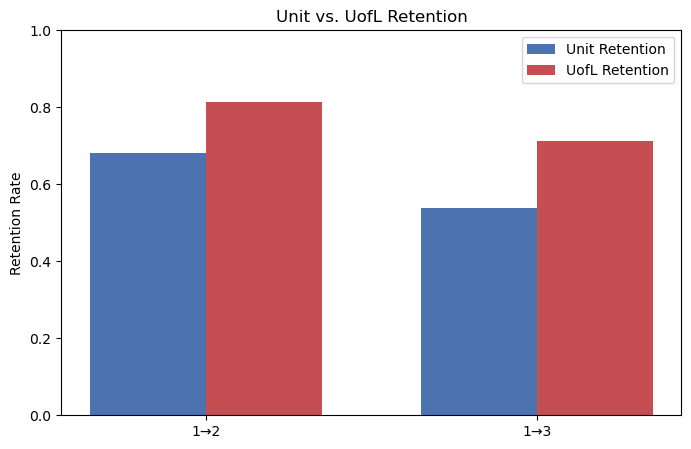

In [8]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['1→2', '1→3']
unit_means = [df['ret_1to2_unit'].mean(), df['ret_1to3_unit'].mean()]
uofl_means = [df['ret_1to2_uofl'].mean(), df['ret_1to3 uofl'].mean()]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, unit_means, width, label='Unit Retention', color='#4C72B0')
plt.bar(x + width/2, uofl_means, width, label='UofL Retention', color='#C44E52')

plt.xticks(x, labels)
plt.ylabel('Retention Rate')
plt.title('Unit vs. UofL Retention')
plt.ylim(0,1)
plt.legend()
plt.show()


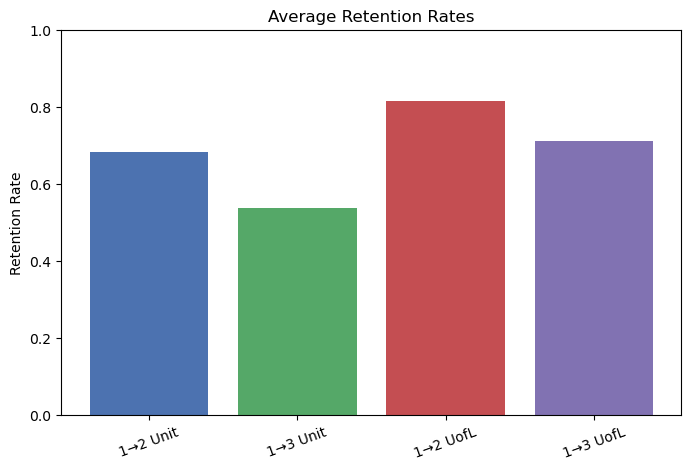

In [9]:
import matplotlib.pyplot as plt

labels = ['1→2 Unit', '1→3 Unit', '1→2 UofL', '1→3 UofL']
values = [
    df['ret_1to2_unit'].mean(),
    df['ret_1to3_unit'].mean(),
    df['ret_1to2_uofl'].mean(),
    df['ret_1to3 uofl'].mean()
]

plt.figure(figsize=(8,5))
plt.bar(labels, values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])

plt.title('Average Retention Rates')
plt.ylabel('Retention Rate')
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.show()


In [11]:
df.groupby('entry_major')['ret_1to2_unit'].mean().sort_values()

entry_major
School of Dentistry                                 0.579836
Kent School of Social Work                          0.621412
College of Arts and Sciences                        0.634433
School of Public Health and Information Sciences    0.649169
University wide                                     0.673895
College of Education and Human Development          0.700778
School of Nursing                                   0.711368
JB Speed School of Engineering                      0.719243
College of Business                                 0.760036
School of Music                                     0.773258
Name: ret_1to2_unit, dtype: float64

In [12]:
df.groupby('entry_major')['cohort_count'].mean()

entry_major
College of Arts and Sciences                        1400.111111
College of Business                                  264.666667
College of Education and Human Development           244.333333
JB Speed School of Engineering                       479.444444
Kent School of Social Work                            23.888889
School of Dentistry                                   38.888889
School of Music                                       77.222222
School of Nursing                                    140.555556
School of Public Health and Information Sciences      30.555556
University wide                                     2699.666667
Name: cohort_count, dtype: float64

In [13]:
df.groupby('entry_major')['ret_1to2_unit'].mean().sort_values()
df.groupby('entry_major')['ret_1to3_unit'].mean().sort_values()


entry_major
School of Dentistry                                 0.344960
Kent School of Social Work                          0.424161
College of Arts and Sciences                        0.479528
School of Public Health and Information Sciences    0.527415
University wide                                     0.537055
College of Education and Human Development          0.552250
School of Nursing                                   0.572192
JB Speed School of Engineering                      0.621867
School of Music                                     0.650222
College of Business                                 0.672081
Name: ret_1to3_unit, dtype: float64